In [349]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
from pathlib import Path
import copy

from tqdm.auto import tqdm
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as VF
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
import open3d as o3d

from config.default import cfg
from lib.datasets.datamodules import DataModule
from lib.models.builder import build_model
from lib.utils.data import data_to_model_device
from transforms3d.quaternions import mat2quat

In [ ]:
def plot_img(img, title, cmap='jet', axis='off', colorbar=True, vrange=None):
    im = plt.imshow(img, cmap=cmap)
    if colorbar:
        plt.colorbar(im, fraction=0.046, pad=0.04, orientation='horizontal')
    plt.title(title)
    plt.axis(axis)

In [ ]:
class Args():
    def __init__(self):
        # self.cfg_path = 'config/rscregrssion/rscr.yaml'
        self.dataset_cfg_path = 'config/sevenscenes.yaml'
        self.checkpoint = 'weights/7s-rscr-v1/version_0/checkpoints/last.ckpt'
        self.split = 'val'
        self.output_root = Path('dev_outputs/')
        # self.scene_root = Path('data/sevenscenes/chess')
        # self.pair_id  =  ('seq-06/frame-000269', 
        #                      'seq-01/frame-000008')
        # self.color_suffix = '.color.png'
        # self.depth_suffix = '.depth.prcnn.png'
        # self.pose_suffix = '.pose.txt'
args = Args()

In [ ]:
cfg.merge_from_file(args.dataset_cfg_path)
# cfg.merge_from_file(args.cfg_path)

In [305]:
dataset = DataModule(cfg).dataset_type(cfg, args.split)
data = dataset[100]

tensor([[ 0.8296,  0.2423, -0.5030,  0.7435],
        [-0.4105,  0.8753, -0.2555, -0.1584],
        [ 0.3784,  0.4185,  0.8257, -0.0987],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])


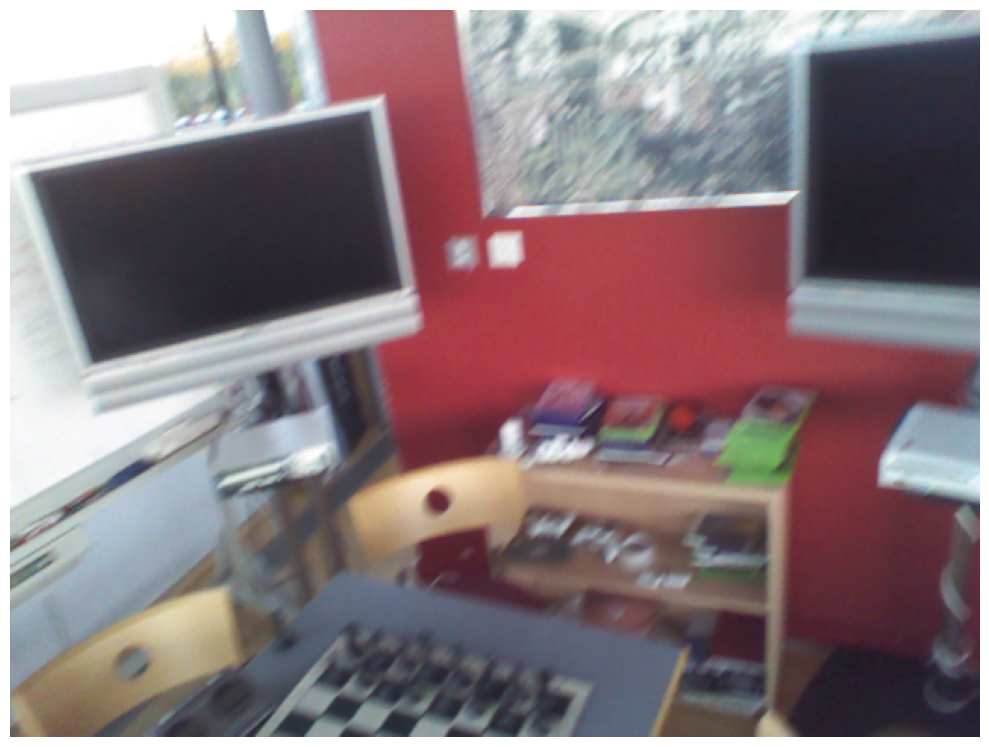

In [367]:
img0 = data['image0'].permute(1, 2, 0)
img1 = data['image1'].permute(1, 2, 0)
img_size = img0.shape[:2]
dep0 = data['depth0'].clip(0, 5)
dep1 = data['depth1'].clip(0, 5)
T_gt_0to1 = data['T_0to1']
K0 = data['K_color0']
K1 = data['K_color1']
print(T_gt_0to1)

plt.figure(figsize=(10, 10))
# plt.subplot(331)
# plot_img(img0, 'img0', colorbar=False)
# plt.subplot(332)
# plot_img(img1, 'img1', colorbar=False)
# plt.subplot(334)
# plot_img(dep0, 'dep0')
# plt.subplot(335)
# plot_img(dep1, 'dep1')

plt.tight_layout()

In [342]:
img0_o3d = o3d.geometry.Image(np.array(img0*255).astype(np.uint8))
dep0_o3d = o3d.geometry.Image(np.array(dep0))
img1_o3d = o3d.geometry.Image(np.array(img1*255).astype(np.uint8))
dep1_o3d = o3d.geometry.Image(np.array(dep1))
rgbd0_o3d = o3d.geometry.RGBDImage.create_from_color_and_depth(img0_o3d, dep0_o3d, 5, convert_rgb_to_intensity=False)
rgbd1_o3d = o3d.geometry.RGBDImage.create_from_color_and_depth(img1_o3d, dep1_o3d, 5, convert_rgb_to_intensity=False)

K0_o3d =  o3d.camera.PinholeCameraIntrinsic(img_size[1], img_size[0], int(K0[0, 0]), int(K0[1, 1]), int(K0[0, 2]), int(K0[1, 2]))
K1_o3d =  o3d.camera.PinholeCameraIntrinsic(img_size[1], img_size[0], int(K1[0, 0]), int(K1[1, 1]), int(K1[0, 2]), int(K1[1, 2]))

pcd0 = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd0_o3d, K0_o3d)
pcd1 = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd1_o3d, K1_o3d)

T = T_gt_0to1.clone()
T[:3, 3] = T[:3, 3] * 0.22
print(np.linalg.norm(T[:3, 3]))
pcd0.transform(T)

cam0_o3d = o3d.geometry.LineSet.create_camera_visualization(K0_o3d, np.eye(4), 0.05)
cam1_o3d = o3d.geometry.LineSet.create_camera_visualization(K1_o3d, np.eye(4), 0.05)
cam0_o3d.transform(T)

coord0_o3d = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)
coord1_o3d = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.03)
coord0_o3d.transform(T)

0.16864476


TriangleMesh with 1134 points and 2240 triangles.

In [ ]:
voxel_size = 0.01
down_pcd0 = pcd0.voxel_down_sample(voxel_size=voxel_size)
down_pcd1 = pcd1.voxel_down_sample(voxel_size=voxel_size)

clr0_o3d = np.asarray([1, 0.706, 0])
clr1_o3d = np.asarray([0.2, 0.5, 1])

# down_pcd0.paint_uniform_color(clr0_o3d)
# cam0_o3d.paint_uniform_color([0,0,0])
down_pcd0.colors = o3d.utility.Vector3dVector(np.asarray(down_pcd0.colors) * 0.2)
cam0_o3d.paint_uniform_color(clr0_o3d)

down_pcd1.paint_uniform_color(clr1_o3d)
cam1_o3d.paint_uniform_color(clr1_o3d * 0.2)
# cam1_o3d.paint_uniform_color(clr1_o3d)

T_shift = np.eye(4)
T_shift[:3, 3] = np.array([0, 1, 0])


o3d.visualization.draw_geometries(
    [
        down_pcd0, 
        down_pcd1, 
        cam0_o3d, cam1_o3d,
        coord0_o3d, coord1_o3d,
    ],
    front=-T[:3, 2].cpu().numpy().reshape(3,1).astype(np.float64),
    up=-T[:3, 1].cpu().numpy().reshape(3,1).astype(np.float64),
    lookat=T[:3, 3].cpu().numpy().reshape(3,1).astype(np.float64),
    zoom=1,
)